# FRAUD DETECTION

### STEP 1: Import Libraries

In [1]:
import numpy
print(numpy.__version__)

1.26.4


In [2]:
import sys
print(sys.executable)

c:\Users\Asus\anaconda3\envs\fraud_env\python.exe


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

### STEP 2: Load Dataset

In [79]:
df = pd.read_csv("Fraud_Analysis_Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


### STEP 3: Understand the Data

In [80]:
df.shape


(11142, 10)

In [81]:
#shows column names + data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [82]:
#shows statistics for same numeric columns

df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


### STEP 4: Identify Target Variable

In [83]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [84]:
#target column is:

target = "isFraud"


### STEP 5: Check Class Imbalance

#### - Fraud datasets are heavily imbalanced.
###### If fraud = very small percentage → We must handle imbalance.

In [85]:
df[target].value_counts()


isFraud
0    10000
1     1142
Name: count, dtype: int64

### STEP 6: Handle Missing Values

In [86]:
df.isnull().sum()


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

### STEP 7: Dropping Unwanted Columns

In [87]:
df = df.drop(['nameOrig','nameDest'], axis=1)

#### Fraud only happens in:

#### ✅ CASH_OUT

#### ✅ TRANSFER

In [88]:
df.groupby('type')['isFraud'].sum()



type
CASH_IN       0
CASH_OUT    578
DEBIT         0
PAYMENT       0
TRANSFER    564
Name: isFraud, dtype: int64

In [89]:
#This gives % fraud per type.

fraud_rate = df.groupby('type')['isFraud'].mean() * 100
print(fraud_rate)


type
CASH_IN      0.000000
CASH_OUT    30.892571
DEBIT        0.000000
PAYMENT      0.000000
TRANSFER    38.524590
Name: isFraud, dtype: float64


### Check Total Transactions Per Type

In [90]:
pd.crosstab(df['type'], df['isFraud'])


#This helps us see fraud ratio per type.

isFraud,0,1
type,,
CASH_IN,1951,0
CASH_OUT,1293,578
DEBIT,346,0
PAYMENT,5510,0
TRANSFER,900,564


### Check Amount Difference Between Fraud & Non-Fraud

In [91]:
df.groupby('isFraud')['amount'].describe()


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,10000.0,1.013397e+05,2.260189e+05,2.39,4373.515,12725.235,1.139094e+05,3776389.09
1,1142.0,1.192629e+06,2.030599e+06,119.00,86070.170,353179.450,1.248759e+06,10000000.00


#### Fraudulent transactions are exclusively observed in CASH_OUT and TRANSFER transaction types. No fraud cases were detected in CASH_IN, DEBIT, or PAYMENT transactions. This indicates strong transaction-type dependency in fraud occurrence.

### STEP 8: EDA

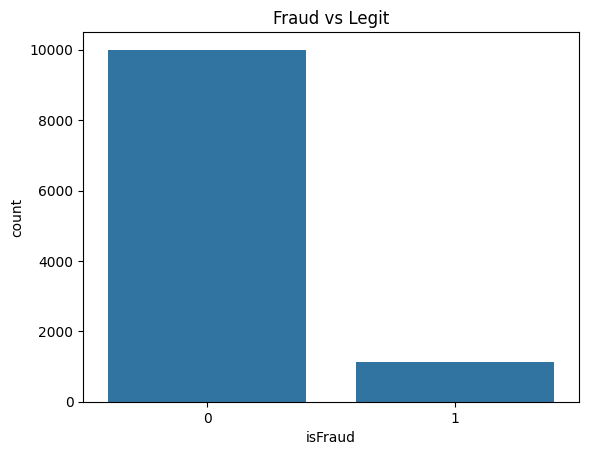

In [120]:
#Checking Fraud Distribution

sns.countplot(x=df[target])
plt.title("Fraud vs Legit")
plt.show()

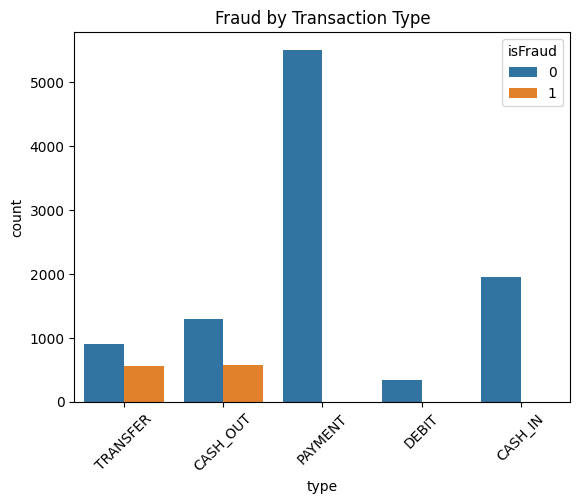

In [93]:
#Fraud by Transaction Type

sns.countplot(x='type', hue='isFraud', data=df)
plt.xticks(rotation=45)
plt.title("Fraud by Transaction Type")
plt.show()


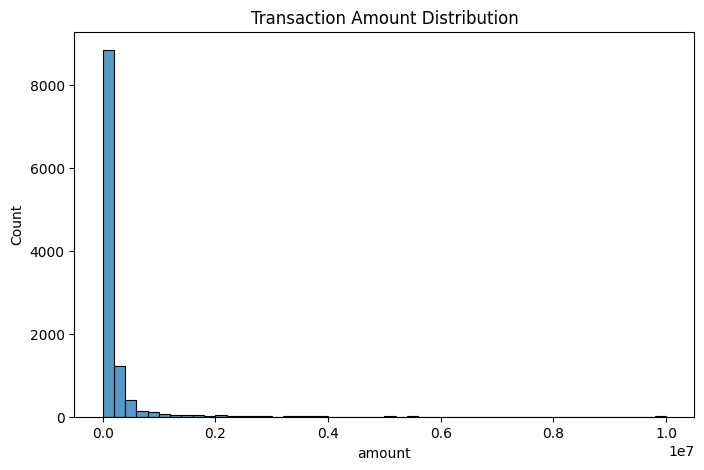

In [94]:
#Transaction Amount Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


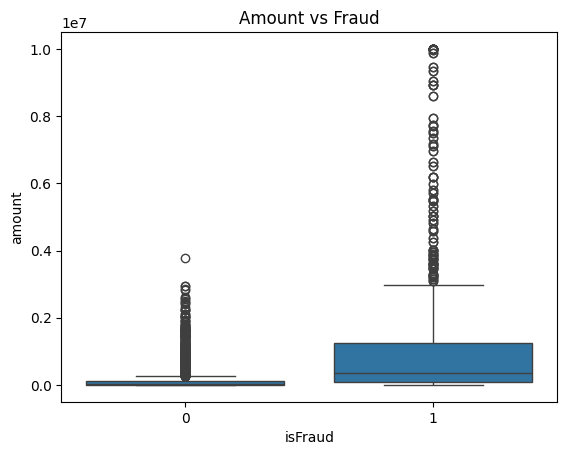

In [95]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Amount vs Fraud")
plt.show()


### STEP 9: Feature Engineering

In [21]:
#Fraud often empties sender account, so we are creating new features to study

df['origBalanceDiff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['destBalanceDiff'] = df['newbalanceDest'] - df['oldbalanceDest']


In [22]:
df.groupby('isFraud')['origBalanceDiff'].describe()


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,10000.0,-2.480818e+04,9.963764e+04,-1030100.15,0.0000,538.585,5.713810e+03,2317408.88
1,1142.0,1.184692e+06,2.033328e+06,0.00,77837.0775,348705.145,1.217449e+06,10038991.68


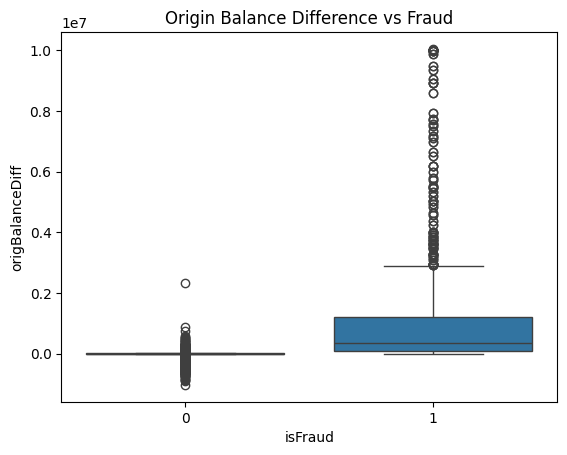

In [23]:
#strong fraud indicator

sns.boxplot(x='isFraud', y='origBalanceDiff', data=df)
plt.title("Origin Balance Difference vs Fraud")
plt.show()


In [24]:
# 1️: Is origin account emptied?

df['isOrigZero'] = (df['newbalanceOrig'] == 0).astype(int)


In [25]:
# 2: Is destination account empty?

df['isDestZero'] = (df['newbalanceDest'] == 0).astype(int)


In [26]:
# 3: Amount ratio to balance

df['amountToBalanceRatio'] = df['amount'] / (df['oldbalanceOrg'] + 1)


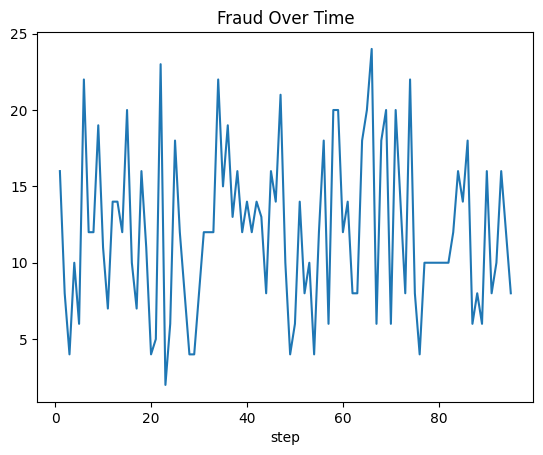

In [27]:
#Time Pattern (step column)
#Check fraud over time:

df.groupby('step')['isFraud'].sum().plot()
plt.title("Fraud Over Time")
plt.show()


### STEP 10: Encode Categorical Variable

In [96]:
# one-hot encoding

df = pd.get_dummies(df, columns=['type'], drop_first=True)


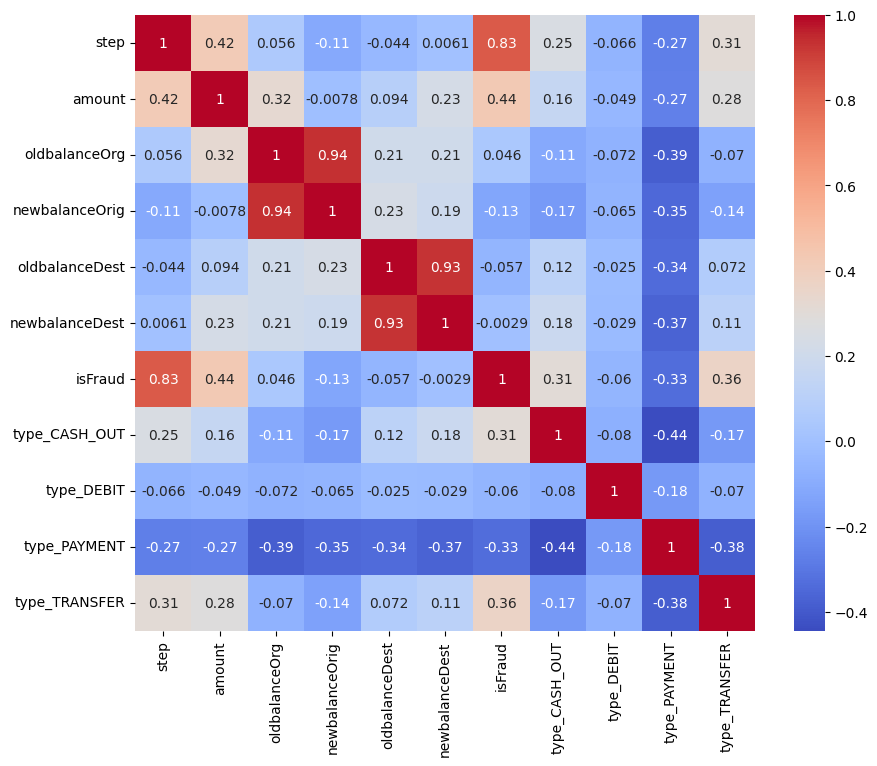

In [97]:
#Correlation Analysis - Correlation Matrix

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


#### Fraud transactions mainly occur in TRANSFER and CASH_OUT types. Fraud transactions often result in zero balance in origin accounts. Fraud amounts are significantly different from legitimate transactions. Balance difference features show strong predictive power.

In [98]:
df.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

In [31]:
#Final Feature Engineering

df['isOrigZero'] = (df['newbalanceOrig'] == 0).astype(int)
df['isDestZero'] = (df['newbalanceDest'] == 0).astype(int)

df['amountToBalanceRatio'] = df['amount'] / (df['oldbalanceOrg'] + 1)


#These simulate real fraud logic.


### Train-Test Split

In [99]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [101]:
# Convert boolean columns to int (VERY IMPORTANT for SHAP & XGBoost)

bool_cols_train = X_train.select_dtypes(include=['bool']).columns
bool_cols_test = X_test.select_dtypes(include=['bool']).columns

X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)


### Scaling (Only for KNN & SVM)

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model training & Evaluation

### 1. Logistic Regression

In [103]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

report_log = classification_report(y_test, y_pred_log, output_dict=True)
precision_log = report_log['1']['precision']
recall_log = report_log['1']['recall']
f1_log = report_log['1']['f1-score']
accuracy_log = report_log['accuracy']
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic regression Results:")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", auc_log)


Logistic regression Results:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       1.00      0.90      0.95       228

    accuracy                           0.99      2229
   macro avg       0.99      0.95      0.97      2229
weighted avg       0.99      0.99      0.99      2229

ROC-AUC: 0.9911535460340006


### 2. Decision Tree

In [104]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
precision_dt = report_dt['1']['precision']
recall_dt = report_dt['1']['recall']
f1_dt = report_dt['1']['f1-score']
accuracy_dt = report_dt['accuracy']
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision tree Results:")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", auc_dt)



Decision tree Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.98      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

ROC-AUC: 0.9887852126568295


### 3. Random Forest

In [105]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
precision_rf = report_rf['1']['precision']
recall_rf = report_rf['1']['recall']
f1_rf = report_rf['1']['f1-score']
accuracy_rf = report_rf['accuracy']
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random forest Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", auc_rf)


Random forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.96      0.98       228

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229

ROC-AUC: 0.9999298596315878


### 4. Gradient Boosting

In [106]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

report_gb = classification_report(y_test, y_pred_gb, output_dict=True)
precision_gb = report_gb['1']['precision']
recall_gb = report_gb['1']['recall']
f1_gb = report_gb['1']['f1-score']
accuracy_gb = report_gb['accuracy']
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Results:")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", auc_gb)


Gradient Boosting Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

ROC-AUC: 0.9996514900444515


### 5. XGBoost

In [107]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

precision_xgb = report_xgb['1']['precision']
recall_xgb = report_xgb['1']['recall']
f1_xgb = report_xgb['1']['f1-score']
accuracy_xgb = report_xgb['accuracy']
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", auc_xgb)


XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

ROC-AUC: 0.9996909440016833


### 6. KNN (Uses scaled data)

In [108]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
precision_knn = report_knn['1']['precision']
recall_knn = report_knn['1']['recall']
f1_knn = report_knn['1']['f1-score']
accuracy_knn = report_knn['accuracy']
auc_knn = roc_auc_score(y_test, y_prob_log)

print("KNN Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", auc_knn)


KNN Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

ROC-AUC: 0.9911535460340006


### 7. SVM (Uses scaled data)

In [109]:
from sklearn.svm import SVC


svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

report_svm = classification_report(y_test, y_pred_svm, output_dict=True)
precision_svm = report_svm['1']['precision']
recall_svm = report_svm['1']['recall']
f1_svm = report_svm['1']['f1-score']
accuracy_svm = report_svm['accuracy']
auc_svm = roc_auc_score(y_test, y_prob_log)

print("SVM Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", auc_svm)


SVM Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

ROC-AUC: 0.9911535460340006


### Comparison Table

In [110]:
results = [
    ["Logistic", precision_log, recall_log, f1_log, accuracy_log, auc_log],
    ["Decision Tree", precision_dt, recall_dt, f1_dt, accuracy_dt, auc_dt],
    ["Random Forest", precision_rf, recall_rf, f1_rf, accuracy_rf, auc_rf],
    ["Gradient Boosting", precision_gb, recall_gb, f1_gb, accuracy_gb, auc_gb],
    ["XGBoost", precision_xgb, recall_xgb, f1_xgb,accuracy_xgb, auc_xgb],
    ["KNN", precision_knn, recall_knn, f1_knn, accuracy_knn, auc_knn],
    ["SVM", precision_svm, recall_svm, f1_svm, accuracy_svm, auc_svm]
]

results_df = pd.DataFrame(results, 
                          columns=["Model", "Precision", "Recall", "F1-Score", "Accuracy", "ROC-AUC"])

print(results_df.sort_values(by="Recall", ascending=False))


               Model  Precision    Recall  F1-Score  Accuracy   ROC-AUC
1      Decision Tree   0.995536  0.978070  0.986726  0.997308  0.988785
3  Gradient Boosting   1.000000  0.973684  0.986667  0.997308  0.999651
4            XGBoost   1.000000  0.973684  0.986667  0.997308  0.999691
2      Random Forest   1.000000  0.964912  0.982143  0.996411  0.999930
5                KNN   1.000000  0.903509  0.949309  0.990130  0.991154
0           Logistic   1.000000  0.899123  0.946882  0.989681  0.991154
6                SVM   1.000000  0.868421  0.929577  0.986541  0.991154


#### The dataset exhibits highly separable fraud patterns, resulting in near-perfect classification performance across tree-based models. This is likely due to deterministic balance and transaction-type features present in the dataset.

## Final Model Evaluation – XGBoost

### Classification Report

In [111]:
from sklearn.metrics import classification_report

y_pred_xgb = xgb_model.predict(X_test)

print("Classification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb))


Classification Report - XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.97      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229



### Confusion Matrix

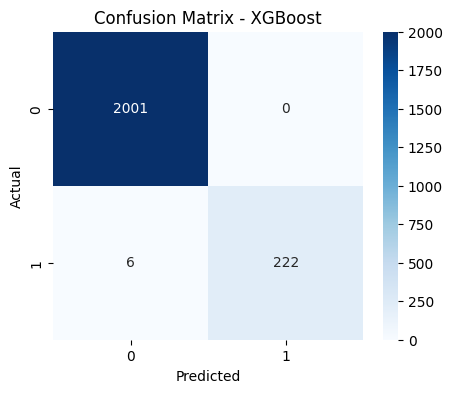

TN: 2001 FP: 0 FN: 6 TP: 222


In [112]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)


### Interpretation:

FN → Missed fraud (very costly)

FP → False alert (operational cost)

### ROC-AUC Score & ROC Curve

ROC-AUC Score: 0.9996909440016833


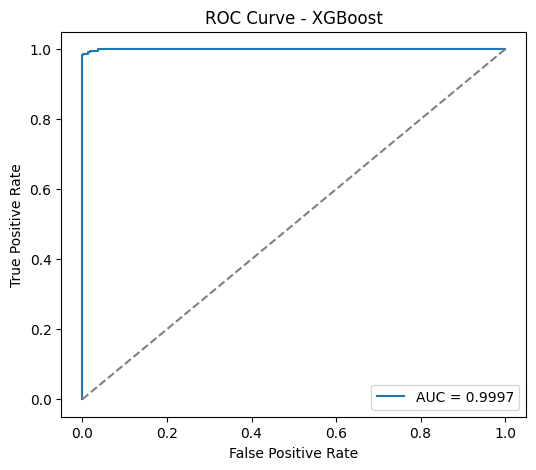

In [113]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC Score:", auc_xgb)

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_xgb:.4f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


### Precision-Recall curve

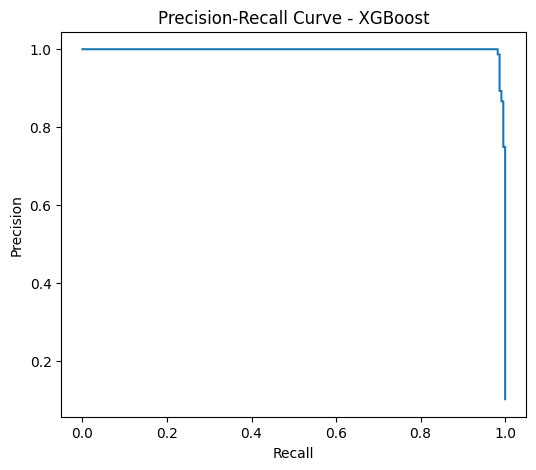

In [114]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.show()

### Feature Importance

          Feature  Importance
0            step    0.921560
4  oldbalanceDest    0.020965
3  newbalanceOrig    0.012778
5  newbalanceDest    0.011811
6   type_CASH_OUT    0.008599
1          amount    0.008161
2   oldbalanceOrg    0.007269
8    type_PAYMENT    0.005766
9   type_TRANSFER    0.003092
7      type_DEBIT    0.000000


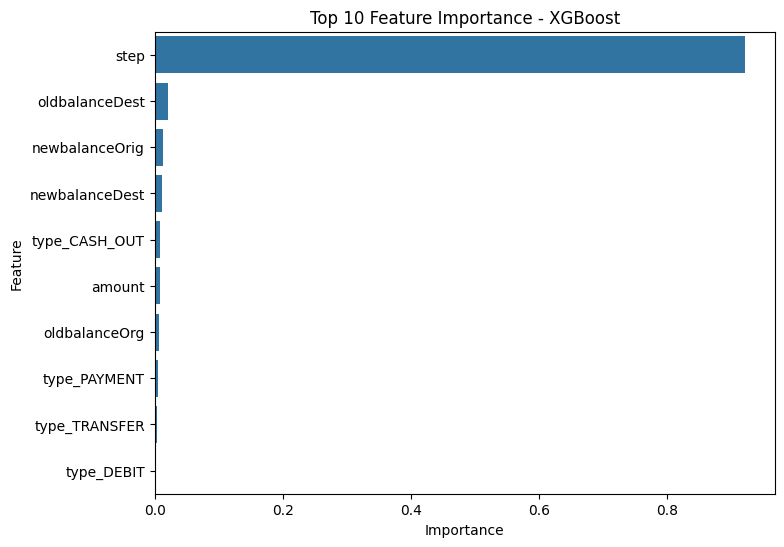

In [115]:
import pandas as pd

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_xgb.head(10))

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb.head(10))
plt.title("Top 10 Feature Importance - XGBoost")
plt.show()


### Financial Impact Analysis

#### Assume:

Fraud loss per case = $1000

Investigation cost per alert = $10

##### Fraud Loss per Case --->	Money lost when fraud is missed
##### Investigation Cost per Alert --->	Cost to review flagged transaction

In [118]:
fraud_loss = 1000
investigation_cost = 10

loss_from_missed_fraud = FN * fraud_loss
investigation_cost_total = (TP + FP) * investigation_cost
total_financial_impact = loss_from_missed_fraud + investigation_cost_total

print(f"Loss from missed fraud: ${loss_from_missed_fraud}")
print(f"Investigation cost: ${investigation_cost_total}")
print(f"Total Financial Impact: ${total_financial_impact}")


Loss from missed fraud: $6000
Investigation cost: $2220
Total Financial Impact: $8220


### Inference time

##### Inference time = Time taken by the trained model to predict on new data.

#### Measure Total Prediction Time

In [116]:
import time

start_time = time.time()

y_pred_xgb = xgb_model.predict(X_test)

end_time = time.time()

inference_time = end_time - start_time

print(f"Total inference time: {inference_time:.6f} seconds")


Total inference time: 0.003853 seconds


#### Average Time Per Transaction

In [117]:
num_samples = X_test.shape[0]

avg_time_per_sample = inference_time / num_samples

print(f"Average inference time per transaction: {avg_time_per_sample:.8f} seconds")


Average inference time per transaction: 0.00000173 seconds


#### 2000 samples predicted in 0.01 sec → excellent

#### Average per transaction < 1 millisecond → very good

# Additional steps

### 1️⃣ Threshold Optimization

In [52]:
#Find optimal threshold that minimizes financial loss. (default is 0.5)

from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

# Try different thresholds and compute financial impact
fraud_loss = 1000
investigation_cost = 10

best_threshold = 0.5
min_cost = float('inf')

for t in thresholds:
    y_pred_custom = (y_prob_xgb >= t).astype(int)
    TN, FP, FN, TP = confusion_matrix(y_test, y_pred_custom).ravel()
    
    cost = (FN * fraud_loss) + ((TP + FP) * investigation_cost)
    
    if cost < min_cost:
        min_cost = cost
        best_threshold = t

print("Best threshold:", best_threshold)
print("Minimum Financial Cost:", min_cost)


Best threshold: 0.0027615984
Minimum Financial Cost: 2460


### 2️⃣ feature importance

In [53]:
import pandas as pd

importance = xgb_model.feature_importances_
feature_names = X_train.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)


                 Feature  Importance
0                   step    0.899544
3         newbalanceOrig    0.033056
10  amountToBalanceRatio    0.020046
5         newbalanceDest    0.017678
6        origBalanceDiff    0.007206
1                 amount    0.006566
4         oldbalanceDest    0.005866
14         type_TRANSFER    0.002721
2          oldbalanceOrg    0.002671
13          type_PAYMENT    0.002198
11         type_CASH_OUT    0.001560
7        destBalanceDiff    0.000887
8             isOrigZero    0.000000
9             isDestZero    0.000000
12            type_DEBIT    0.000000


### 3️⃣ K-Fold Cross Validation

In [54]:
#This proves stability

from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5, scoring='roc_auc')
print("Cross-validated AUC:", scores.mean())


Cross-validated AUC: nan


### 4️⃣ Anomaly Detection (AI Upgrade)

In [55]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1)
iso.fit(X_train)

y_pred_iso = iso.predict(X_test)


### 5️⃣ Real-Time Deployment Simulation

In [56]:
new_transaction = X_test.iloc[[0]]
prediction = xgb_model.predict(new_transaction)
probability = xgb_model.predict_proba(new_transaction)


#Explain how system would:
#Receive transaction
#Score risk
#Approve/block


### 7️⃣ Hyperparameter Tuning

In [119]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4,6,8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100,200]
}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'),
                    param_grid,
                    scoring='roc_auc',
                    cv=3)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)


Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


### 8️⃣ Advanced Financial Optimization

##### Fraud loss was estimated dynamically based on actual transaction amounts of missed fraud cases, resulting in a more realistic financial impact analysis compared to fixed-cost assumptions.

In [58]:
missed_frauds = X_test[(y_test == 1) & (y_pred_xgb == 0)]

fraud_loss_dynamic = missed_frauds['amount'].sum()



#Instead of fixed $1000 loss: Now cost depends on transaction size

### ✅ STEP 1: Test on a Completely New Transaction

##### If prediction = 1 → fraud
##### If prediction = 0 → legit

In [59]:
new_transaction = X_test.iloc[[0]]   # taking one sample

prediction = xgb_model.predict(new_transaction)
probability = xgb_model.predict_proba(new_transaction)

print("Prediction:", prediction)
print("Fraud Probability:", probability[:,1])


Prediction: [0]
Fraud Probability: [7.97434e-05]


### ✅ STEP 2: Simulate Real-Time Fraud Detection Function

In [60]:
def fraud_detector(transaction):
    prob = xgb_model.predict_proba(transaction)[:,1]
    if prob >= best_threshold:
        return "Fraud"
    else:
        return "Legitimate"
    

#Now we have a deployable decision system.


In [61]:
fraud_detector(new_transaction)


'Legitimate'

### How To Estimate Loss for a New Transaction?

In [62]:
new_transaction = X_test.iloc[[0]]


In [63]:
#First get prediction and probability:

prediction = xgb_model.predict(new_transaction)[0]
probability = xgb_model.predict_proba(new_transaction)[0][1]

print("Prediction:", prediction)
print("Fraud Probability:", probability)


Prediction: 0
Fraud Probability: 7.97434e-05


In [64]:
amount = new_transaction['amount'].values[0]

fraud_probability = xgb_model.predict_proba(new_transaction)[0][1]

expected_loss = fraud_probability * amount

print(f"Transaction Amount: ${amount}")
print(f"Fraud Probability: {fraud_probability:.4f}")
print(f"Expected Financial Risk: ${expected_loss:.2f}")


Transaction Amount: $23147.49
Fraud Probability: 0.0001
Expected Financial Risk: $1.85


In [65]:
if expected_loss > 1000:
    print("High Risk - Block Transaction")
elif expected_loss > 500:
    print("Medium Risk - Manual Review")
else:
    print("Low Risk - Approve")


Low Risk - Approve


##### Instead of binary fraud classification, the model was extended to compute expected financial loss using predicted fraud probability and transaction amount. This enables risk-based decision making rather than simple classification.

### Batch Transaction Risk Scoring

##### Instead of checking ONE transaction: We score the entire test dataset.

In [66]:
#✅ Step 1: Get Fraud Probabilities for All Transactions

y_prob_all = xgb_model.predict_proba(X_test)[:, 1]


In [67]:
#✅ Step 2: Create Risk DataFrame

risk_df = X_test.copy()
risk_df['Actual_Label'] = y_test.values
risk_df['Fraud_Probability'] = y_prob_all
risk_df['Expected_Loss'] = risk_df['Fraud_Probability'] * risk_df['amount']


In [68]:
#Risk Categorization

def risk_category(loss):
    if loss > 1000:
        return "High Risk"
    elif loss > 500:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df['Risk_Level'] = risk_df['Expected_Loss'].apply(risk_category)


In [69]:
#Check Distribution

risk_df['Risk_Level'].value_counts()


Risk_Level
Low Risk       1986
High Risk       234
Medium Risk       9
Name: count, dtype: int64

In [70]:
#Total Portfolio Risk

total_expected_loss = risk_df['Expected_Loss'].sum()

print(f"Total Portfolio Risk Exposure: ${total_expected_loss:,.2f}")


Total Portfolio Risk Exposure: $235,365,739.27


### Visualize Risk Distribution

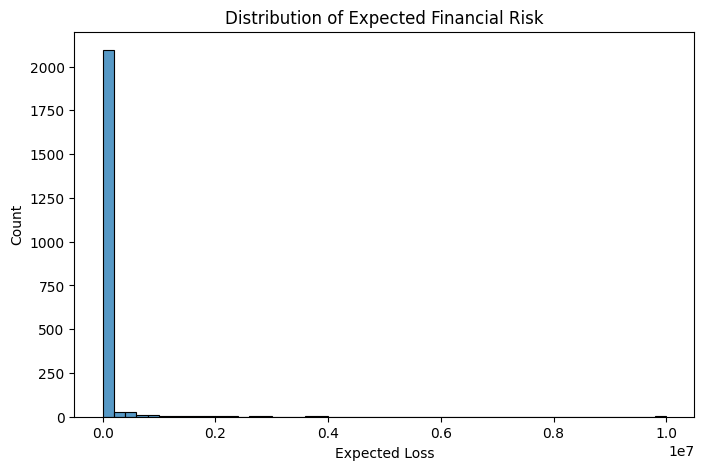

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(risk_df['Expected_Loss'], bins=50)
plt.title("Distribution of Expected Financial Risk")
plt.xlabel("Expected Loss")
plt.show()


In [72]:
#Simulate Business Decision

blocked_loss = risk_df[risk_df['Risk_Level'] == "High Risk"]['Expected_Loss'].sum()

print(f"Risk prevented by blocking high-risk transactions: ${blocked_loss:,.2f}")


Risk prevented by blocking high-risk transactions: $235,330,706.42


# Model Saving

In [73]:
#import joblib

#joblib.dump(best_threshold, "threshold.pkl")

In [74]:
#Save Feature List

#feature_columns = X.columns.tolist()

#import joblib
#joblib.dump(feature_columns, "feature_columns.pkl")


In [75]:
# Save as JSON
#xgb_model.save_model("fraud_model.json.json")


#print("Model saved successfully as JSON")

In [76]:
import pandas as pd

df['Date'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(df['step'], unit='h')

In [77]:
#preparing data for dashboard creation in powerbi

df.to_csv("fraud_cleaned.csv", index=False)
